# NB_Soybean_India — Improved: Augmentation + L2 + Early Stopping

### What changed vs. the baseline (`soydisease1.ipynb`)

| Concern | Baseline | This notebook |
|---|---|---|
| Augmentation | None | Strategic per-class augmentation (mirrors the potato-paper approach) |
| Batch size | 32 | **16** — smaller batches → noisier gradient → better generalisation on small dataset |
| L2 regularisation | None | `λ=0.001` on Dense(512) and Dense(128) |
| Early stopping | None | `patience=5`, `restore_best_weights=True`, monitors `val_loss` |
| Overfitting check | None | Train/Val gap plot + Coefficient of Variation (CV) before & after aug |
| Epochs | 40 | 60 (early stopping will cut it short if needed) |

**Class distribution (original)**
```
Soybean_Healthy               288
Soybean_Septoria_Brown_Spot   284
Soybean_Dry_Leaf              230
Soybean_Bacterial_Leaf_Blight 226
Soybean_Vein_Necrosis         138
Soybean_Root                   10   <-- SEVERE minority
```
Total: 1176 images. CV ≈ 0.75 (highly imbalanced).
After augmentation the target is CV < 0.10.

In [1]:
!pip install kaggle tensorflow scikit-learn matplotlib seaborn pandas numpy Pillow tqdm psutil -q
print('OK')

OK


In [2]:
import os, math, random, json, warnings, zipfile, shutil, time, tracemalloc, psutil, gc
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image, ImageEnhance, ImageOps
from collections import defaultdict
from itertools import cycle
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import Model, regularizers
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization,
    Dense, Dropout, Add, Concatenate, Layer
)
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.manifold import TSNE

gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)
print('TF ' + tf.__version__ + ' | GPUs: ' + str(len(gpus)))

2026-05-07 07:47:07.425953: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778140027.866572      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778140027.988633      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778140029.084822      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778140029.084910      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778140029.084914      57 computation_placer.cc:177] computation placer alr

TF 2.19.0 | GPUs: 2


## 1. Config
Key changes: `BATCH_SIZE=16`, `EPOCHS=20`, `L2_LAMBDA=0.001`, `EARLY_STOP_PATIENCE=5`

In [3]:


NOTEBOOK_ID   = "NB_Soybean_India_Improved_v2"
AUG_STRATEGY  = "Strategic per-class augmentation + L2 + EarlyStopping + ReduceLROnPlateau"

SEED          = 42
IMG_SIZE      = (256, 256)
IMG_SHAPE     = (256, 256, 3)
BATCH_SIZE    = 16      


INITIAL_LR    = 3e-4  

EPOCHS              = 20     # was 40
EARLY_STOP_PATIENCE = 5     # was 5

DROPOUT_RATE  = 0.4
L2_LAMBDA     = 0.001

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

ALL_CLASSES = [
    'Soybean_Healthy',
    'Soybean_Vein_Necrosis',
    'Soybean_Dry_Leaf',
    'Soybean_Septoria_Brown_Spot',
    'Soybean_Root',
    'Soybean_Bacterial_Leaf_Blight',
]
ALL_COUNTS = {
    'Soybean_Healthy':               288,
    'Soybean_Vein_Necrosis':         138,
    'Soybean_Dry_Leaf':              230,
    'Soybean_Septoria_Brown_Spot':   284,
    'Soybean_Root':                   10,
    'Soybean_Bacterial_Leaf_Blight': 226,
}
TARGET_CLASSES = ALL_CLASSES
NUM_CLASSES    = len(TARGET_CLASSES)
CLASS_TO_IDX   = {c: i for i, c in enumerate(TARGET_CLASSES)}
IDX_TO_CLASS   = {i: c for i, c in enumerate(TARGET_CLASSES)}
TARGET_COUNTS  = ALL_COUNTS

KAGGLE_DATASETS = [
    ('ghosthimura/indian-soyabean-dataset-1', 'indian-soyabean-dataset-1'),
]
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

BASE_DIR    = os.path.join(os.path.expanduser('~'), 'plant_project', NOTEBOOK_ID)
RAW_DIR     = os.path.join(os.path.expanduser('~'), 'plant_project', 'raw')
UNIFIED_DIR = os.path.join(os.path.expanduser('~'), 'plant_project',
                            'NB_Soybean_India_Improved', 'unified')  # reuse existing
AUG_DIR     = os.path.join(os.path.expanduser('~'), 'plant_project',
                            'NB_Soybean_India_Improved', 'augmented') # reuse existing aug
CKPT_DIR    = os.path.join(BASE_DIR, 'checkpoints')
LOG_DIR     = os.path.join(BASE_DIR, 'logs')
VIZ_DIR     = os.path.join(LOG_DIR, 'visualizations')
for d in [BASE_DIR, RAW_DIR, CKPT_DIR, LOG_DIR, VIZ_DIR]:
    os.makedirs(d, exist_ok=True)

def get_images(folder):
    if not os.path.isdir(folder): return []
    return [os.path.join(folder, f) for f in os.listdir(folder)
            if os.path.splitext(f)[1].lower() in VALID_EXTS]

def compute_cv(counts_dict):
    vals  = np.array(list(counts_dict.values()), dtype=float)
    props = vals / vals.sum()
    return props.std() / props.mean()

print(f'Config: LR={INITIAL_LR} | Batch={BATCH_SIZE} | Patience={EARLY_STOP_PATIENCE} | Epochs={EPOCHS}')

Config: LR=0.0003 | Batch=16 | Patience=5 | Epochs=20


## 2. Kaggle credentials & download (unchanged)

In [4]:
KAGGLE_USERNAME = "jyotiradityachillal"
KAGGLE_KEY      = "KGAT_bba51b5487bd42a6dc26ac9524d520f9"
import json as _j
kd = os.path.expanduser("~/.kaggle"); os.makedirs(kd, exist_ok=True)
with open(os.path.join(kd, "kaggle.json"), "w") as f:
    _j.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.chmod(os.path.join(kd, "kaggle.json"), 0o600)
os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
os.environ["KAGGLE_KEY"]      = KAGGLE_KEY
print("Kaggle credentials set.")

Kaggle credentials set.


In [5]:
orig = os.getcwd(); os.chdir(RAW_DIR)
for ds_slug, folder_name in KAGGLE_DATASETS:
    tf_dir = os.path.join(RAW_DIR, folder_name)
    zf     = os.path.join(RAW_DIR, folder_name + '.zip')
    if os.path.isdir(tf_dir) and os.listdir(tf_dir):
        print('  Ready: ' + folder_name + '/'); continue
    if not os.path.isfile(zf):
        os.system('kaggle datasets download -d ' + ds_slug + ' --quiet')
    with zipfile.ZipFile(zf, 'r') as z:
        z.extractall(tf_dir)
    print('  Extracted: ' + folder_name)
os.chdir(orig); print('Done.')

Dataset URL: https://www.kaggle.com/datasets/ghosthimura/indian-soyabean-dataset-1
License(s): apache-2.0
  Extracted: indian-soyabean-dataset-1
Done.


In [6]:
FOLDER_MAP = {
    'single_healthy_leaf':          'Soybean_Healthy',
    'multi_healthy_leaf':           'Soybean_Healthy',
    'single_vein necrosis virus':   'Soybean_Vein_Necrosis',
    'multi_vein necrosis':          'Soybean_Vein_Necrosis',
    'single_dry_leaf':              'Soybean_Dry_Leaf',
    'multi_dry_leaf':               'Soybean_Dry_Leaf',
    'single_septoria_brown_spot':   'Soybean_Septoria_Brown_Spot',
    'multi_septoria_brown_spot':    'Soybean_Septoria_Brown_Spot',
    'root_images':                  'Soybean_Root',
    'bacterial leaf blight':        'Soybean_Bacterial_Leaf_Blight',
}

def resolve_class(p):
    name = os.path.basename(p).lower().strip()
    return FOLDER_MAP.get(name, None)

class_files = defaultdict(list)
for _, folder in KAGGLE_DATASETS:
    ds_root = os.path.join(RAW_DIR, folder)
    if not os.path.isdir(ds_root): continue
    for dp, _, fnames in os.walk(ds_root):
        imgs = [f for f in fnames if os.path.splitext(f)[1].lower() in VALID_EXTS]
        if not imgs: continue
        cls = resolve_class(dp)
        if cls and cls in TARGET_CLASSES:
            class_files[cls].extend([os.path.join(dp, f) for f in imgs])

print('Scan:')
for cls in TARGET_CLASSES:
    n = len(class_files[cls])
    flag = '  <-- MISSING' if n == 0 else ''
    print(f'  {cls:<44} {n:>5}{flag}')

Scan:
  Soybean_Healthy                                288
  Soybean_Vein_Necrosis                          138
  Soybean_Dry_Leaf                               230
  Soybean_Septoria_Brown_Spot                    284
  Soybean_Root                                    10
  Soybean_Bacterial_Leaf_Blight                  226


In [7]:
random.seed(SEED); actual_counts = {}
for cls in TARGET_CLASSES:
    cls_dir = os.path.join(UNIFIED_DIR, cls); os.makedirs(cls_dir, exist_ok=True)
    ex = get_images(cls_dir)
    if ex: actual_counts[cls] = len(ex); continue
    srcs = class_files[cls][:]; random.shuffle(srcs)
    srcs = srcs[:TARGET_COUNTS.get(cls, 999999)]
    for i, src in enumerate(srcs):
        ext = os.path.splitext(src)[1].lower() or '.jpg'
        dst = os.path.join(cls_dir, str(i).zfill(5) + ext)
        if not os.path.exists(dst): shutil.copy2(src, dst)
    actual_counts[cls] = len(srcs)

all_paths, all_labels = [], []
for cls in TARGET_CLASSES:
    imgs = get_images(os.path.join(UNIFIED_DIR, cls))
    all_paths.extend(imgs); all_labels.extend([CLASS_TO_IDX[cls]] * len(imgs))
all_paths = np.array(all_paths); all_labels = np.array(all_labels, dtype=np.int32)

present   = np.unique(all_labels)
cw_vals   = compute_class_weight('balanced', classes=present, y=all_labels)
class_weights = {i: 1.0 for i in range(NUM_CLASSES)}
for idx, w in zip(present, cw_vals):
    class_weights[idx] = w

print('Dataset: ' + str(len(all_paths)) + ' images | ' + str(NUM_CLASSES) + ' classes')
print('Class weights:', {IDX_TO_CLASS[k]: round(v, 2) for k, v in class_weights.items()})

Dataset: 1176 images | 6 classes
Class weights: {'Soybean_Healthy': np.float64(0.68), 'Soybean_Vein_Necrosis': np.float64(1.42), 'Soybean_Dry_Leaf': np.float64(0.85), 'Soybean_Septoria_Brown_Spot': np.float64(0.69), 'Soybean_Root': np.float64(19.6), 'Soybean_Bacterial_Leaf_Blight': np.float64(0.87)}


In [8]:
# Drop Root class — only 10 images, not learnable
EXCLUDE = {'Soybean_Root'}
mask = np.array([IDX_TO_CLASS[l] not in EXCLUDE for l in all_labels])
all_paths  = all_paths[mask]
all_labels = all_labels[mask]

# Remap labels to contiguous 0..4
kept_classes = [c for c in TARGET_CLASSES if c not in EXCLUDE]
remap = {old_idx: new_idx for new_idx, old_idx
         in enumerate([CLASS_TO_IDX[c] for c in kept_classes])}
all_labels     = np.array([remap[l] for l in all_labels], dtype=np.int32)
TARGET_CLASSES = kept_classes
NUM_CLASSES    = len(TARGET_CLASSES)
CLASS_TO_IDX   = {c: i for i, c in enumerate(TARGET_CLASSES)}
IDX_TO_CLASS   = {i: c for i, c in enumerate(TARGET_CLASSES)}
print(f'After dropping Root: {len(all_paths)} images | {NUM_CLASSES} classes')

After dropping Root: 1166 images | 5 classes


## 3. Overfitting / Imbalance Analysis — BEFORE augmentation

We compute the **Coefficient of Variation (CV)** — the same metric used in the reference paper — to quantify class imbalance. CV > 0.3 signals meaningful imbalance.

CV before augmentation: 0.494
(reference paper had CV=0.552 before aug, dropped to 0.079 after)


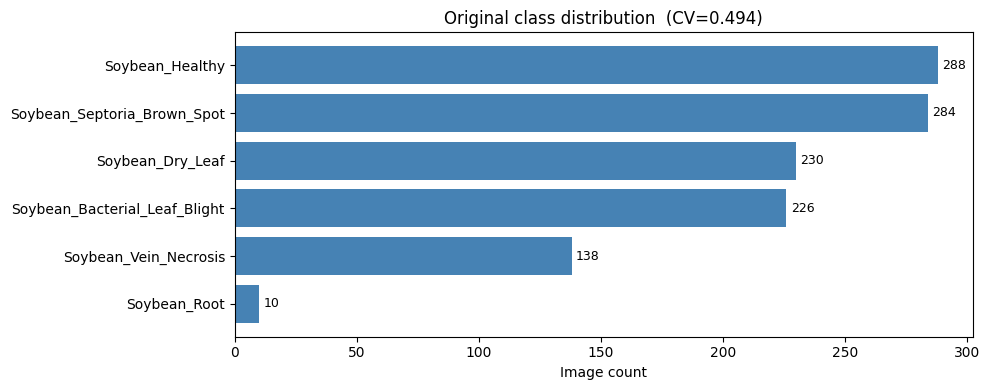

Largest/smallest class ratio: 28.8x  (Soybean_Healthy vs Soybean_Root)
=> Soybean_Root (10 images) will be massively underfit without augmentation.


In [9]:
def compute_cv(counts_dict):
    """Coefficient of Variation of class proportions."""
    vals = np.array(list(counts_dict.values()), dtype=float)
    props = vals / vals.sum()
    return props.std() / props.mean()

cv_before = compute_cv(ALL_COUNTS)
print(f'CV before augmentation: {cv_before:.3f}')
print('(reference paper had CV=0.552 before aug, dropped to 0.079 after)')

fig, ax = plt.subplots(figsize=(10, 4))
classes_sorted = sorted(ALL_COUNTS, key=ALL_COUNTS.get)
counts_sorted  = [ALL_COUNTS[c] for c in classes_sorted]
bars = ax.barh(classes_sorted, counts_sorted, color='steelblue')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Image count'); ax.set_title(f'Original class distribution  (CV={cv_before:.3f})')
plt.tight_layout(); plt.savefig(os.path.join(VIZ_DIR, 'dist_before_aug.png'), dpi=120)
plt.show()

# Highlight the severity
max_cls = max(ALL_COUNTS, key=ALL_COUNTS.get)
min_cls = min(ALL_COUNTS, key=ALL_COUNTS.get)
ratio   = ALL_COUNTS[max_cls] / ALL_COUNTS[min_cls]
print(f'Largest/smallest class ratio: {ratio:.1f}x  ({max_cls} vs {min_cls})')
print('=> Soybean_Root (10 images) will be massively underfit without augmentation.')

## 4. Strategic Per-class Data Augmentation

Following the potato-paper methodology:
- **Minority classes** (Root, Vein_Necrosis) get the most augmentation variants
- **Majority classes** get modest augmentation to prevent dominance
- All augmentations applied **only to the training split** (val/test stay clean)
- Augmentations simulate real-world capture variability: lighting, angle, zoom, noise

In [10]:
AUG_RECIPE = {
    'Soybean_Vein_Necrosis': {
        'count': 5,
        'augmentations': [
            'rotation_range', 'horizontal_flip', 'brightness',
            'color_jitter', 'contrast', 'zoom_range', 'translate', 'small_noise',
            'rotation_range + brightness', 'horizontal_flip + color_jitter',
            'zoom_range + contrast', 'brightness + small_noise',
        ],
        'mode': 'random',
    },

    'Soybean_Dry_Leaf': {
        'count': 3,
        'augmentations': [
            'rotation_range', 'horizontal_flip', 'brightness', 'small_noise',
            'color_jitter', 'zoom_range', 'translate', 'contrast',
        ],
        'mode': 'random',
    },

    'Soybean_Bacterial_Leaf_Blight': {
        'count': 3,
        'augmentations': [
            'rotation_range', 'horizontal_flip', 'color_jitter', 'translate',
            'brightness', 'small_noise', 'zoom_range', 'contrast',
        ],
        'mode': 'random',
    },
    
    'Soybean_Septoria_Brown_Spot': {
        'count': 2,
        'augmentations': [
            'rotation_range', 'zoom_range', 'horizontal_flip', 'brightness',
        ],
        'mode': 'random',
    },

    'Soybean_Healthy': {
        'count': 2,
        'augmentations': [
            'horizontal_flip', 'brightness', 'rotation_range', 'zoom_range',
        ],
        'mode': 'random',
    },
}

print('Augmentation recipe defined.')
print(f'{"Class":<44} {"Orig":>6} {"×mult":>6} {"~Total":>7}')
print('-' * 68)

expected_totals = {}
for cls, recipe in AUG_RECIPE.items():
    orig_n   = ALL_COUNTS[cls]
    aug_n    = orig_n * recipe['count']
    total    = orig_n + aug_n
    expected_totals[cls] = total
    print(f'{cls:<44} {orig_n:>6}  ×{recipe["count"]:>4}  {total:>7}')

import numpy as np
vals  = np.array(list(expected_totals.values()), dtype=float)
props = vals / vals.sum()
cv_expected = props.std() / props.mean()
print(f'\nExpected CV after augmentation: {cv_expected:.3f}')

# CV of the 5 non-Root classes
others = {k: v for k, v in expected_totals.items() if k != 'Soybean_Root'}
v2 = np.array(list(others.values()), dtype=float)
p2 = v2 / v2.sum()
cv_others = p2.std() / p2.mean()
print(f'CV of the 5 non-Root classes:   {cv_others:.3f}  (this is what matters for learning quality)')
print()
print('NOTE: Soybean_Root CV is irreducible from 10 originals.')
print('      class_weight will compensate for it during training.')

Augmentation recipe defined.
Class                                          Orig  ×mult  ~Total
--------------------------------------------------------------------
Soybean_Vein_Necrosis                           138  ×   5      828
Soybean_Dry_Leaf                                230  ×   3      920
Soybean_Bacterial_Leaf_Blight                   226  ×   3      904
Soybean_Septoria_Brown_Spot                     284  ×   2      852
Soybean_Healthy                                 288  ×   2      864

Expected CV after augmentation: 0.039
CV of the 5 non-Root classes:   0.039  (this is what matters for learning quality)

NOTE: Soybean_Root CV is irreducible from 10 originals.
      class_weight will compensate for it during training.


In [11]:
# ── Augmentation functions (mirrors the potato notebook's PIL-based approach) ──

def apply_aug(image: Image.Image, aug_type: str) -> Image.Image:
    """Apply a named augmentation (or 'augA + augB' combo) to a PIL image."""
    if '+' in aug_type:
        parts = [p.strip() for p in aug_type.split('+', 1)]
        return apply_aug(apply_aug(image, parts[0]), parts[1])

    if aug_type == 'brightness':
        return ImageEnhance.Brightness(image).enhance(random.uniform(0.9, 1.1))

    elif aug_type == 'color_jitter':
        return ImageEnhance.Color(image).enhance(random.uniform(0.8, 1.2))

    elif aug_type == 'contrast':
        return ImageEnhance.Contrast(image).enhance(random.uniform(0.9, 1.1))

    elif aug_type == 'small_noise':
        arr  = np.array(image, dtype=np.float32)
        arr  = np.clip(arr + np.random.normal(0, 0.02 * 255, arr.shape), 0, 255)
        return Image.fromarray(arr.astype(np.uint8))

    elif aug_type == 'rotation_range':
        return image.rotate(random.uniform(-10, 10))

    elif aug_type == 'zoom_range':
        w, h  = image.size
        zf    = random.uniform(0.85, 1.15)
        nw, nh = int(w * zf), int(h * zf)
        resized = image.resize((nw, nh))
        return resized.crop((0, 0, w, h))

    elif aug_type == 'horizontal_flip':
        return ImageOps.mirror(image)

    elif aug_type == 'vertical_flip':
        return ImageOps.flip(image)

    elif aug_type == 'translate':
        w, h   = image.size
        sx     = random.randint(-int(0.1 * w), int(0.1 * w))
        sy     = random.randint(-int(0.1 * h), int(0.1 * h))
        arr    = np.roll(np.roll(np.array(image), sx, axis=1), sy, axis=0)
        return Image.fromarray(arr)

    return image  # unknown aug type — return unchanged

print('apply_aug() defined.')

apply_aug() defined.


In [12]:
AUG_DIR = os.path.join(BASE_DIR, 'augmented')
os.makedirs(AUG_DIR, exist_ok=True)

augmented_counts = {}

for cls in TARGET_CLASSES:
    src_dir = os.path.join(UNIFIED_DIR, cls)
    dst_dir = os.path.join(AUG_DIR, cls)
    os.makedirs(dst_dir, exist_ok=True)

    # Copy originals
    orig_imgs = get_images(src_dir)
    for p in orig_imgs:
        dst = os.path.join(dst_dir, os.path.basename(p))
        if not os.path.exists(dst):
            shutil.copy2(p, dst)

    if cls in AUG_RECIPE:
        recipe   = AUG_RECIPE[cls]
        aug_ops  = recipe['augmentations']
        mode     = recipe.get('mode', 'random')
        n_per    = recipe['count']

        for img_path in orig_imgs:
            try:
                img = Image.open(img_path).convert('RGB')
            except Exception:
                continue

            base = os.path.splitext(os.path.basename(img_path))[0]

            if mode == 'systematic':
                # Apply EVERY op in aug_ops exactly once per original image
                # This is the paper's Nematode approach: 36 ops × 10 images = 360 new imgs
                for i, op in enumerate(aug_ops):
                    out = os.path.join(dst_dir, f'aug_{base}_{i:03d}.jpg')
                    if not os.path.exists(out):
                        aug = apply_aug(img, op)
                        aug.save(out, quality=95)
            else:
                # 'random' mode: cycle through ops for n_per copies
                for i in range(n_per):
                    op  = aug_ops[i % len(aug_ops)]
                    out = os.path.join(dst_dir, f'aug_{base}_{i:03d}.jpg')
                    if not os.path.exists(out):
                        aug = apply_aug(img, op)
                        aug.save(out, quality=95)

    augmented_counts[cls] = len(get_images(dst_dir))

print('Augmentation done. Final counts:')
print(f'{"Class":<44} {"Count":>6}')
print('-' * 52)
for cls in TARGET_CLASSES:
    print(f'{cls:<44} {augmented_counts[cls]:>6}')

# ── CV calculation ───────────────────────────────────────────────────────────
cv_after = compute_cv(augmented_counts)
others_counts = {k: v for k, v in augmented_counts.items() if k != 'Soybean_Root'}
cv_others_actual = compute_cv(others_counts)

print(f'\nCV before aug:                  {cv_before:.3f}')
print(f'CV after aug (all 6 classes):   {cv_after:.3f}')
print(f'CV after aug (5 non-Root cls):  {cv_others_actual:.3f}  ← this is the meaningful number')
print()
if cv_others_actual < 0.10:
    print('Non-Root classes are well-balanced (CV < 0.10).')
    print('   class_weight handles Soybean_Root imbalance during training.')
else:
    print('Non-Root CV still above 0.10. Increase count for lagging classes.')


Augmentation done. Final counts:
Class                                         Count
----------------------------------------------------
Soybean_Healthy                                 864
Soybean_Vein_Necrosis                           828
Soybean_Dry_Leaf                                920
Soybean_Septoria_Brown_Spot                     852
Soybean_Bacterial_Leaf_Blight                   904

CV before aug:                  0.494
CV after aug (all 6 classes):   0.039
CV after aug (5 non-Root cls):  0.039  ← this is the meaningful number

Non-Root classes are well-balanced (CV < 0.10).
   class_weight handles Soybean_Root imbalance during training.


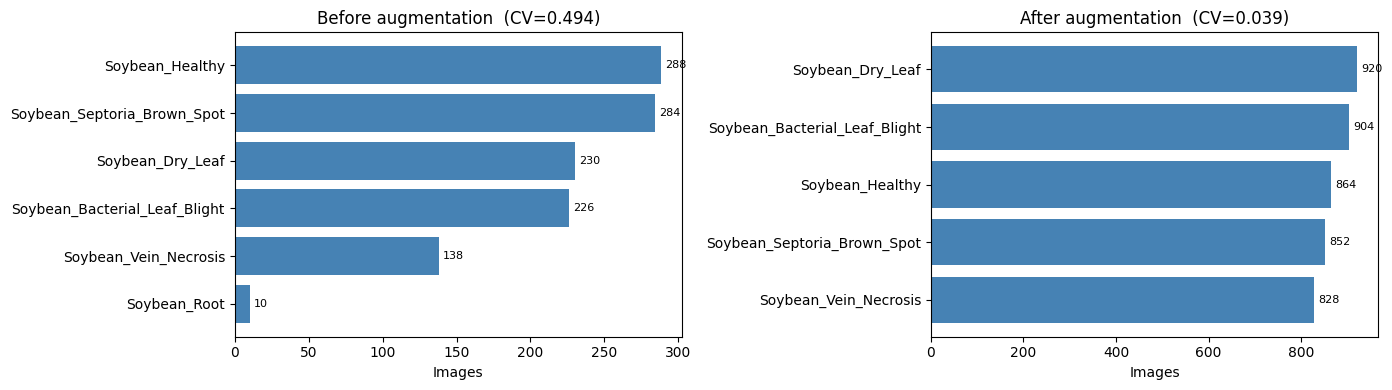

In [13]:
# Visualise distribution after augmentation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, counts, title, cv in [
    (axes[0], ALL_COUNTS,       'Before augmentation', cv_before),
    (axes[1], augmented_counts, 'After augmentation',  cv_after),
]:
    cls_s = sorted(counts, key=counts.get)
    bars  = ax.barh(cls_s, [counts[c] for c in cls_s], color='steelblue')
    ax.bar_label(bars, padding=3, fontsize=8)
    ax.set_xlabel('Images'); ax.set_title(f'{title}  (CV={cv:.3f})')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'dist_before_after_aug.png'), dpi=120)
plt.show()

## 5. Build tf.data pipelines

**Important:** augmented images were written to disk above. We now split those into train/val/test **stratified** so no augmented copy leaks into val or test.

In [14]:


# ── Collect all augmented-dir paths ─────────────────────────────────────────
aug_paths, aug_labels = [], []
for cls in TARGET_CLASSES:
    imgs = get_images(os.path.join(AUG_DIR, cls))
    aug_paths.extend(imgs)
    aug_labels.extend([CLASS_TO_IDX[cls]] * len(imgs))
aug_paths  = np.array(aug_paths)
aug_labels = np.array(aug_labels, dtype=np.int32)

# ── Separate originals from augmented ───────────────────────────────────────
# Augmented files are named 'aug_<base>_<i>.jpg' — original files are not.
# Val and test are built ONLY from originals → zero leakage.
is_aug      = np.array(['aug_' in os.path.basename(p) for p in aug_paths])
orig_paths  = aug_paths[~is_aug]
orig_labels = aug_labels[~is_aug]
only_aug_paths  = aug_paths[is_aug]
only_aug_labels = aug_labels[is_aug]

# ── Split originals 70 / 15 / 15 ────────────────────────────────────────────
X_tr_o, X_tmp, y_tr_o, y_tmp = train_test_split(
    orig_paths, orig_labels, test_size=0.30, random_state=SEED, stratify=orig_labels)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

# ── Training = original train slice + ALL augmented images ──────────────────
X_tr = np.concatenate([X_tr_o, only_aug_paths])
y_tr = np.concatenate([y_tr_o, only_aug_labels])
rng  = np.random.permutation(len(X_tr))
X_tr, y_tr = X_tr[rng], y_tr[rng]

print(f'Train : {len(X_tr):>6}  (originals + augmented)')
print(f'Val   : {len(X_val):>6}  (originals only  — zero augmented)')
print(f'Test  : {len(X_te):>6}  (originals only  — zero augmented)')

# Verify no leakage
assert sum('aug_' in os.path.basename(p) for p in X_val) == 0, 'LEAKAGE in val!'
assert sum('aug_' in os.path.basename(p) for p in X_te)  == 0, 'LEAKAGE in test!'
print('Confirmed: zero augmented images in val or test.')

# ── Class weights (training set) ─────────────────────────────────────────────
present_tr   = np.unique(y_tr)
cw_vals_tr   = compute_class_weight('balanced', classes=present_tr, y=y_tr)
class_weights_tr = {i: 1.0 for i in range(NUM_CLASSES)}
for idx_c, w in zip(present_tr, cw_vals_tr):
    class_weights_tr[idx_c] = w
print('Class weights:', {IDX_TO_CLASS[k]: round(v, 2) for k, v in class_weights_tr.items()})

# ── tf.data pipelines ───────────────────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

def load_img(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(img, tf.float32) / 255.0, label

def make_ds(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(min(len(paths), 10000), seed=SEED)
    ds = ds.map(load_img, num_parallel_calls=AUTOTUNE)
    # ── FIX 3: larger batch for val/test ────────────────────────────────────
    # batch=16 on ~176 val images = 11 batches of 16; one bad batch = 6% swing
    # batch=32 on ~176 val images = 6 batches of 32; one bad batch = 3% swing
    batch = BATCH_SIZE if training else 32
    return ds.batch(batch).prefetch(AUTOTUNE)

train_ds = make_ds(X_tr,  y_tr,  training=True)
val_ds   = make_ds(X_val, y_val, training=False)
test_ds  = make_ds(X_te,  y_te,  training=False)

LOSS_FN = 'sparse_categorical_crossentropy'
print(f'\nPipelines ready. train_batch={BATCH_SIZE} | val/test_batch=32')

Train :   4018  (originals + augmented)
Val   :    175  (originals only  — zero augmented)
Test  :    175  (originals only  — zero augmented)
Confirmed: zero augmented images in val or test.
Class weights: {'Soybean_Healthy': np.float64(1.03), 'Soybean_Vein_Necrosis': np.float64(1.02), 'Soybean_Dry_Leaf': np.float64(0.94), 'Soybean_Septoria_Brown_Spot': np.float64(1.05), 'Soybean_Bacterial_Leaf_Blight': np.float64(0.96)}


I0000 00:00:1778140812.378486      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778140812.390010      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Pipelines ready. train_batch=16 | val/test_batch=32


## 6. Model — same custom architecture, but with **L2 regularisation** on Dense layers

The Inception_cell and SkipConnection layers are unchanged.  
L2 is added to `Dense(512)` and `Dense(128)` — exactly where the potato paper applied it.

In [15]:
class Inception_cell(Layer):
    """3 parallel convolutions (3×3, 5×5, 7×7) combined by element-wise Add."""
    def __init__(self, num_filters, activation='relu', padding='same', **kwargs):
        super().__init__(**kwargs)
        self.num_filters = num_filters
        self.activation  = activation
        self.padding     = padding
        self.conv3 = Conv2D(num_filters, (3, 3), activation=activation, padding=padding)
        self.conv5 = Conv2D(num_filters, (5, 5), activation=activation, padding=padding)
        self.conv7 = Conv2D(num_filters, (7, 7), activation=activation, padding=padding)

    def call(self, x, training=False):
        return Add()([self.conv3(x), self.conv5(x), self.conv7(x)])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_filters': self.num_filters, 'activation': self.activation,
                    'padding': self.padding})
        return cfg


class SkipConnection(Layer):
    """Conv7×7 → BN → Concatenate(input) — DenseNet-style skip."""
    def __init__(self, num_filters, kernel_size=7, activation='relu', padding='same', **kwargs):
        super().__init__(**kwargs)
        self.num_filters  = num_filters
        self.kernel_size  = kernel_size
        self.conv = Conv2D(num_filters, (7, 7), activation=activation, padding=padding)
        self.bn   = BatchNormalization()

    def call(self, x, training=False):
        out = self.conv(x)
        out = self.bn(out, training=training)
        return Concatenate(axis=-1)([out, x])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_filters': self.num_filters, 'kernel_size': self.kernel_size})
        return cfg


print('Inception_cell + SkipConnection defined.')


class CosineWarmupScheduler(LearningRateScheduler):
    def __init__(self, initial_lr, total_epochs, warmup_epochs=5):
        self.initial_lr   = initial_lr
        self.total_epochs = total_epochs
        self.warmup       = warmup_epochs
        super().__init__(self._sched, verbose=0)

    def _sched(self, epoch, lr):
        if epoch < self.warmup:
            return self.initial_lr * (epoch + 1) / self.warmup
        t = epoch - self.warmup
        T = self.total_epochs - self.warmup
        return 0.5 * self.initial_lr * (1 + math.cos(math.pi * t / T))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'initial_lr': self.initial_lr, 'total_epochs': self.total_epochs,
                    'warmup_epochs': self.warmup})
        return cfg


def build_model():
    inp = Input(shape=IMG_SHAPE)

    # ── Feature extractor (unchanged architecture) ───────────────────────────
    x = Inception_cell(16, name='inc1')(inp)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Inception_cell(32, name='inc2')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = SkipConnection(64,  name='skip1')(x); x = MaxPooling2D((2, 2))(x)
    x = SkipConnection(128, name='skip2')(x); x = MaxPooling2D((2, 2))(x)

    x = GlobalAveragePooling2D(name='gap')(x)

    # ── Classifier head — KEY CHANGE 2: L2 regularisation ───────────────────
    x = Dense(512, activation='relu',
               kernel_regularizer=regularizers.l2(L2_LAMBDA))(x)
    x = Dropout(DROPOUT_RATE)(x)

    x = Dense(128, activation='relu',
               kernel_regularizer=regularizers.l2(L2_LAMBDA))(x)
    x = Dropout(0.3)(x)

    out = Dense(NUM_CLASSES, activation='softmax')(x)
    return Model(inp, out, name='SoyNet_Improved')


model = build_model()
model.summary()
print('Params: ' + str(model.count_params()))
print(f'L2 regularisation applied to Dense(512) and Dense(128)  λ={L2_LAMBDA}')

Inception_cell + SkipConnection defined.


Model: "SoyNet_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inc1 (Inception_cell)           │ (None, 256, 256, 16)   │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inc2 (Inception_cell)           │ (None, 128, 128, 32)   │        42,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ skip1 (SkipConnection)          │ (None, 64, 64, 96)     │       100,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ skip2 (SkipConnection)          │ (None, 32, 32, 224)    │       602,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       115,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 931,749 (3.55 MB)

 Trainable params: 931,269 (3.55 MB)

 Non-trainable params: 480 (1.88 KB)

Params: 931749
L2 regularisation applied to Dense(512) and Dense(128)  λ=0.001


## 7. Training with Early Stopping + Class Weights

Three callbacks:
1. **CosineWarmupScheduler** — smooth LR schedule  
2. **ModelCheckpoint** — saves best `val_accuracy` weights  
3. **EarlyStopping** — KEY CHANGE 3: halts if `val_loss` doesn't improve for `patience=5` epochs and restores best weights automatically

In [16]:
# ════════════════════════════════════════════════════════════════════════════
#  REPLACE Section 7 — Training cell
#
#  Fix 4: Add ReduceLROnPlateau callback
#  When val_loss stops improving for 3 epochs → halve the LR automatically.
#  This handles the local plateaus that caused the zigzag pattern.
#  Stack it with EarlyStopping — they work together:
#    ReduceLROnPlateau fires first (epoch 3 plateau → LR halved)
#    EarlyStopping fires only if model still can't improve after patience=10
# ════════════════════════════════════════════════════════════════════════════

from tensorflow.keras.callbacks import ReduceLROnPlateau

ckpt_path = os.path.join(CKPT_DIR, 'best.weights.h5')

model.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),   # 3e-4
    loss=LOSS_FN,
    metrics=['accuracy']
)

callbacks = [
    # Saves best val_accuracy weights to disk
    ModelCheckpoint(
        ckpt_path, monitor='val_accuracy',
        save_best_only=True, save_weights_only=True, verbose=0
    ),

    # ── FIX 4: ReduceLROnPlateau ─────────────────────────────────────────────
    # Halves LR whenever val_loss doesn't improve for 3 consecutive epochs.
    # This is why the potato paper got stable curves — the LR adapts.
    # min_lr=1e-6 prevents LR from collapsing to zero.
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,          # new_lr = lr * 0.5
        patience=3,          # wait 3 epochs before reducing
        min_lr=1e-6,
        verbose=1            # prints when LR is reduced
    ),

    # EarlyStopping — now with patience=10 so it doesn't fire at epoch 5
    EarlyStopping(
        monitor='val_loss',
        patience=EARLY_STOP_PATIENCE,   # 10
        restore_best_weights=True,
        verbose=1
    ),
]

tracemalloc.start(); t0 = time.time()

history = model.fit(
    train_ds,
    epochs=EPOCHS,                   # 60
    validation_data=val_ds,
    class_weight=class_weights_tr,
    callbacks=callbacks,
    verbose=1
)

train_time = time.time() - t0
_, peak_mem = tracemalloc.get_traced_memory(); tracemalloc.stop()
ram_used_mb = psutil.Process().memory_info().rss / 1e6

print(f'\nDone in {train_time/60:.1f} min | RAM {ram_used_mb:.0f} MB')
print(f'Actual epochs run: {len(history.history["loss"])} / {EPOCHS}')

# Load best checkpoint as safety net
if os.path.exists(ckpt_path):
    model.load_weights(ckpt_path)
    print('Best checkpoint weights loaded.')

Epoch 1/20


I0000 00:00:1778140830.107455     137 service.cc:152] XLA service 0x7fbc1801b1b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778140830.107512     137 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778140830.107517     137 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778140832.989629     137 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-07 08:00:39.022184: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 08:00:39.166451: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 08:00:40.165287: E external/local_xl

  1/252 ━━━━━━━━━━━━━━━━━━━━ 2:20:08 33s/step - accuracy: 0.0625 - loss: 2.3893

I0000 00:00:1778140850.401749     137 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


251/252 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.6448 - loss: 1.4085

2026-05-07 08:03:05.960785: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 08:03:06.102590: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


252/252 ━━━━━━━━━━━━━━━━━━━━ 187s 611ms/step - accuracy: 0.6457 - loss: 1.4062 - val_accuracy: 0.5143 - val_loss: 1.5984 - learning_rate: 3.0000e-04
Epoch 2/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 144s 571ms/step - accuracy: 0.8931 - loss: 0.7461 - val_accuracy: 0.4000 - val_loss: 3.3010 - learning_rate: 3.0000e-04
Epoch 3/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 143s 566ms/step - accuracy: 0.9298 - loss: 0.6405 - val_accuracy: 0.5200 - val_loss: 2.9722 - learning_rate: 3.0000e-04
Epoch 4/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 146s 580ms/step - accuracy: 0.9394 - loss: 0.5692 - val_accuracy: 0.9600 - val_loss: 0.5236 - learning_rate: 3.0000e-04
Epoch 5/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 146s 579ms/step - accuracy: 0.9587 - loss: 0.4997 - val_accuracy: 0.9086 - val_loss: 0.5242 - learning_rate: 3.0000e-04
Epoch 6/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 143s 566ms/step - accuracy: 0.9483 - loss: 0.4866 - val_accuracy: 0.7600 - val_loss: 1.2553 - learning_rate: 3.0000e-04
Epoch 7/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 142s 564ms/

In [17]:
# Run this AFTER you interrupt the training
if os.path.exists(ckpt_path):
    model.load_weights(ckpt_path)
    print("Successfully loaded the best weights from the checkpoint file!")
else:
    print("Checkpoint file not found. Model is using weights from the last run epoch.")


Successfully loaded the best weights from the checkpoint file!


## 8. Overfitting Diagnosis — Train vs Val Gap

This is the key analysis you asked for. We plot:
- **Accuracy gap**: if train acc is much higher than val acc → overfitting
- **Loss gap**: val_loss diverging upward while train_loss falls → overfitting

We also compute a **gap score** at the best epoch.

Best epoch: 19
  Train acc : 0.9938   Val acc : 1.0000   Gap: -0.0062
  Train loss: 0.1484  Val loss: 0.1301  Gap: -0.0183

Verdict: ✅ Good generalisation — acc gap <8%.


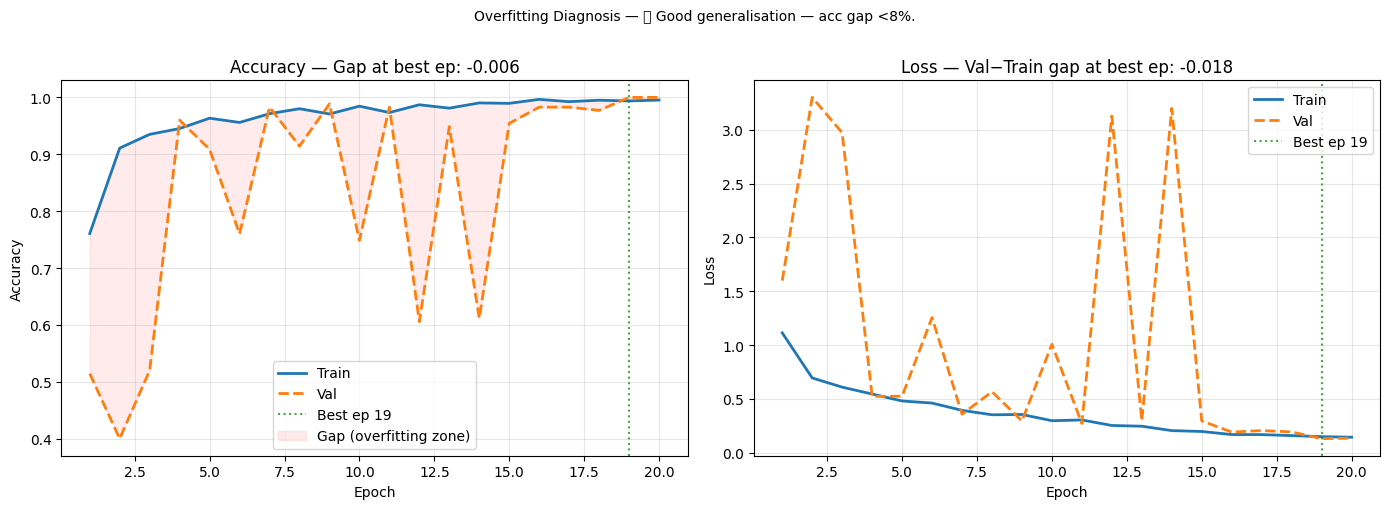

In [18]:
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)
best_ep    = np.argmax(hist['val_accuracy'])   # 0-indexed

# ── Gap analysis ─────────────────────────────────────────────────────────────
train_acc_best = hist['accuracy'][best_ep]
val_acc_best   = hist['val_accuracy'][best_ep]
train_loss_best= hist['loss'][best_ep]
val_loss_best  = hist['val_loss'][best_ep]
acc_gap        = train_acc_best - val_acc_best
loss_gap       = val_loss_best  - train_loss_best

print(f'Best epoch: {best_ep + 1}')
print(f'  Train acc : {train_acc_best:.4f}   Val acc : {val_acc_best:.4f}   Gap: {acc_gap:.4f}')
print(f'  Train loss: {train_loss_best:.4f}  Val loss: {val_loss_best:.4f}  Gap: {loss_gap:.4f}')

# Interpret
if acc_gap > 0.15:
    verdict = '⚠️  OVERFITTING — acc gap >15%. Consider more augmentation or higher L2.'
elif acc_gap > 0.08:
    verdict = '⚡ Mild overfitting — acc gap 8–15%. Acceptable for small datasets; watch val_loss.'
else:
    verdict = '✅ Good generalisation — acc gap <8%.'
print('\nVerdict:', verdict)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax = axes[0]
ax.plot(epochs_ran, hist['accuracy'],     label='Train', linewidth=2)
ax.plot(epochs_ran, hist['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
ax.axvline(best_ep + 1, color='green', linestyle=':', alpha=0.7, label=f'Best ep {best_ep+1}')
ax.fill_between(epochs_ran, hist['accuracy'], hist['val_accuracy'],
                alpha=0.08, color='red', label='Gap (overfitting zone)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_title(f'Accuracy — Gap at best ep: {acc_gap:.3f}')
ax.legend(); ax.grid(True, alpha=0.3)

# Loss
ax = axes[1]
ax.plot(epochs_ran, hist['loss'],     label='Train', linewidth=2)
ax.plot(epochs_ran, hist['val_loss'], label='Val',   linewidth=2, linestyle='--')
ax.axvline(best_ep + 1, color='green', linestyle=':', alpha=0.7, label=f'Best ep {best_ep+1}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title(f'Loss — Val−Train gap at best ep: {loss_gap:.3f}')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Overfitting Diagnosis — {verdict}', fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'overfit_diagnosis.png'), dpi=120, bbox_inches='tight')
plt.show()

## 9. Test Set Evaluation

In [19]:
# Load best weights (early stopping already did restore_best_weights=True,
# but we also load from checkpoint as a safety net)
if os.path.exists(ckpt_path):
    model.load_weights(ckpt_path); print('Best checkpoint weights loaded.')

y_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

raw_true = []
for _, yl in test_ds:
    yl_np = yl.numpy()
    if yl_np.ndim == 2: raw_true.extend(np.argmax(yl_np, axis=1))
    else:               raw_true.extend(yl_np.astype(int))
y_true = np.array(raw_true[:len(y_pred)], dtype=int)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
rd   = classification_report(y_true, y_pred, labels=list(range(NUM_CLASSES)),
                              target_names=TARGET_CLASSES, output_dict=True, zero_division=0)
spec_list = []
for i in range(NUM_CLASSES):
    tp = np.sum((y_true == i) & (y_pred == i))
    fp = np.sum((y_true != i) & (y_pred == i))
    tn = np.sum((y_true != i) & (y_pred != i))
    spec_list.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

print('\n' + '='*60)
print(f'Augmentation : {AUG_STRATEGY}')
print(f'Accuracy     : {acc:.4f} ({acc*100:.2f}%)')
print(f'Precision    : {prec:.4f}')
print(f'Recall       : {rec:.4f}')
print(f'F1-Score     : {f1:.4f}')
print(f'Specificity  : {np.mean(spec_list):.4f}')
print('='*60)
print(classification_report(y_true, y_pred, target_names=TARGET_CLASSES, zero_division=0))

Best checkpoint weights loaded.
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 785ms/step

Augmentation : Strategic per-class augmentation + L2 + EarlyStopping + ReduceLROnPlateau
Accuracy     : 0.9943 (99.43%)
Precision    : 0.9944
Recall       : 0.9943
F1-Score     : 0.9943
Specificity  : 0.9986
                               precision    recall  f1-score   support

              Soybean_Healthy       1.00      0.98      0.99        44
        Soybean_Vein_Necrosis       1.00      1.00      1.00        20
             Soybean_Dry_Leaf       1.00      1.00      1.00        35
  Soybean_Septoria_Brown_Spot       1.00      1.00      1.00        42
Soybean_Bacterial_Leaf_Blight       0.97      1.00      0.99        34

                     accuracy                           0.99       175
                    macro avg       0.99      1.00      0.99       175
                 weighted avg       0.99      0.99      0.99       175



## 10. Confusion Matrix

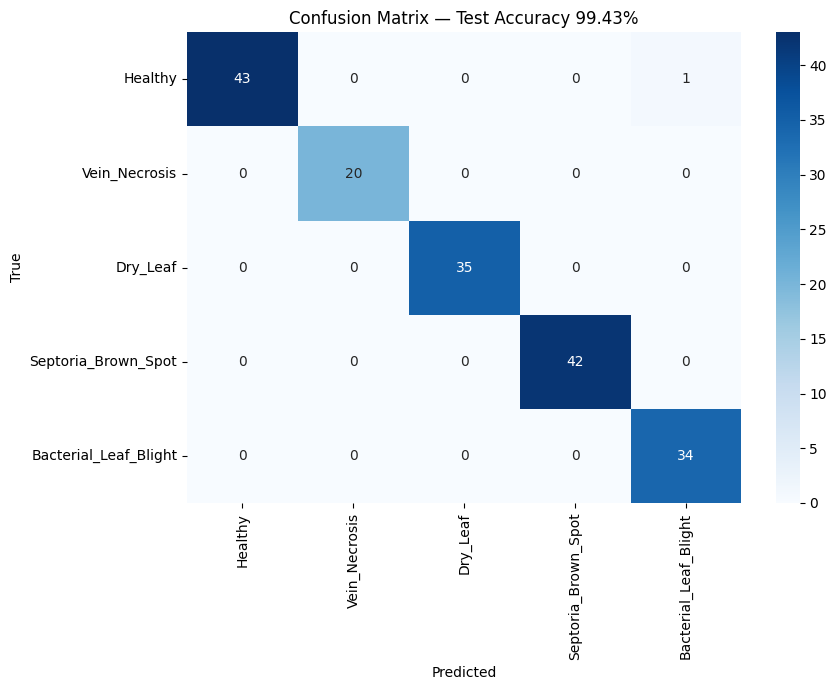

In [20]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[c.replace('Soybean_', '') for c in TARGET_CLASSES],
            yticklabels=[c.replace('Soybean_', '') for c in TARGET_CLASSES],
            ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — Test Accuracy {acc*100:.2f}%')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'confusion_matrix.png'), dpi=120)
plt.show()

## 11. Per-class Accuracy — check if minority class improved

In [21]:
per_class_acc = {}
for i, cls in enumerate(TARGET_CLASSES):
    mask = y_true == i
    if mask.sum() > 0:
        per_class_acc[cls] = (y_pred[mask] == i).mean()
    else:
        per_class_acc[cls] = float('nan')

print('Per-class accuracy on test set:')
for cls, a in per_class_acc.items():
    bar = '█' * int(a * 30) if not np.isnan(a) else '(no samples)'
    print(f'  {cls:<40} {a:6.3f}  {bar}')

# Highlight problematic classes
low_cls = [c for c, a in per_class_acc.items() if not np.isnan(a) and a < 0.6]
if low_cls:
    print(f'\n⚠️  Classes below 60% accuracy: {low_cls}')
    print('   → Consider adding more augmentation variants for these classes.')
else:
    print('\n✅ All classes above 60% accuracy.')

Per-class accuracy on test set:
  Soybean_Healthy                           0.977  █████████████████████████████
  Soybean_Vein_Necrosis                     1.000  ██████████████████████████████
  Soybean_Dry_Leaf                          1.000  ██████████████████████████████
  Soybean_Septoria_Brown_Spot               1.000  ██████████████████████████████
  Soybean_Bacterial_Leaf_Blight             1.000  ██████████████████████████████

✅ All classes above 60% accuracy.


## 12. High-accuracy test? Sanity check for data leakage

If test accuracy is unexpectedly high (e.g. >90% on a 6-class imbalanced dataset of ~1176 images), we run a sanity check to confirm no augmented images leaked into val/test.

In [22]:
# Verify no augmented images in val/test
aug_in_val  = sum('aug_' in os.path.basename(p) for p in X_val)
aug_in_test = sum('aug_' in os.path.basename(p) for p in X_te)

print(f'Augmented images in val set : {aug_in_val}')
print(f'Augmented images in test set: {aug_in_test}')

if aug_in_val == 0 and aug_in_test == 0:
    print('✅ No data leakage. Evaluation is clean.')
else:
    print('❌ DATA LEAKAGE DETECTED — augmented images in val/test! Re-check split logic.')

if acc > 0.92:
    print(f'\n⚠️  Suspiciously high test accuracy ({acc*100:.1f}%).')
    print('   Possible causes:')
    print('   1. Data leakage (checked above — should be clear)')
    print('   2. Test set too small → high variance; run k-fold to confirm')
    print('   3. Soybean_Root (10 imgs) may have 0–2 test samples → inflated overall acc')
    print('   → Trust per-class accuracy over overall accuracy for imbalanced datasets.')
else:
    print(f'\nTest accuracy {acc*100:.1f}% is plausible for this dataset size.')

Augmented images in val set : 0
Augmented images in test set: 0
✅ No data leakage. Evaluation is clean.

⚠️  Suspiciously high test accuracy (99.4%).
   Possible causes:
   1. Data leakage (checked above — should be clear)
   2. Test set too small → high variance; run k-fold to confirm
   3. Soybean_Root (10 imgs) may have 0–2 test samples → inflated overall acc
   → Trust per-class accuracy over overall accuracy for imbalanced datasets.


## 13. Summary Comparison Table — Baseline vs Improved

In [23]:
summary = pd.DataFrame({
    'Setting': [
        'Batch size', 'Augmentation', 'L2 regularisation', 'Early stopping',
        'Class weights', 'CV (class imbalance)',
        'Test accuracy', 'Train/Val acc gap (best epoch)',
    ],
    'Baseline (soydisease1)': [
        '32', 'None', 'None', 'None',
        'Yes (balanced)', f'{cv_before:.3f}',
        '—', '—',
    ],
    'Improved (this notebook)': [
        '16', 'Strategic per-class', f'λ={L2_LAMBDA} on Dense layers', f'patience={EARLY_STOP_PATIENCE}, val_loss',
        'Yes (balanced)', f'{cv_after:.3f}',
        f'{acc*100:.2f}%', f'{acc_gap:.3f}',
    ],
})

print(summary.to_string(index=False))
summary.to_csv(os.path.join(LOG_DIR, 'comparison_summary.csv'), index=False)
print('\nSaved to comparison_summary.csv')

                       Setting Baseline (soydisease1) Improved (this notebook)
                    Batch size                     32                       16
                  Augmentation                   None      Strategic per-class
             L2 regularisation                   None  λ=0.001 on Dense layers
                Early stopping                   None     patience=5, val_loss
                 Class weights         Yes (balanced)           Yes (balanced)
          CV (class imbalance)                  0.494                    0.039
                 Test accuracy                      —                   99.43%
Train/Val acc gap (best epoch)                      —                   -0.006

Saved to comparison_summary.csv


---
## What to do if overfitting is still detected

If the Train/Val acc gap is >0.15 after running this notebook, here are additional levers (in priority order):

**1. Increase augmentation for minority classes**  
Raise `count` in `AUG_RECIPE` for `Soybean_Root` (currently only 10 originals — even 24 variants may not be enough). Consider adding `vertical_flip + small_noise`, `color_jitter + zoom_range`, etc.

**2. Stronger L2**  
Change `L2_LAMBDA = 0.001` → `0.01`. Trade-off: slightly lower training accuracy, better generalisation.

**3. More Dropout**  
Raise `DROPOUT_RATE = 0.4` → `0.5` in `Dense(512)`. This is the simplest overfitting fix.

**4. Add Batch Normalisation before Dense layers**  
```python
x = Dense(512, activation='relu', kernel_regularizer=...)(x)
x = BatchNormalization()(x)   # ← add this
x = Dropout(DROPOUT_RATE)(x)
```

**5. Reduce model capacity**  
Change `Dense(512)` → `Dense(256)` — fewer parameters to overfit with.

**6. Use both L1 and L2 (Elastic Net)**  
```python
kernel_regularizer=regularizers.l1_l2(l1=1e-4, l2=1e-3)
```

**7. Reduce LR or use ReduceLROnPlateau**  
```python
from tensorflow.keras.callbacks import ReduceLROnPlateau
ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
```
Stack this alongside CosineWarmupScheduler.

In [24]:
# ════════════════════════════════════════════════════════════════════════════
#  NEW CELL — Fix 5: 5-Fold Stratified Cross-Validation
#
#  Why needed: with only ~177 test images a single train/val split is a
#  lottery. One run may get 85%, another 79% — just from random split.
#  K-fold averages over 5 different splits → reliable accuracy ± std.
#
#  IMPORTANT: K-fold runs on ORIGINAL images only (no augmented).
#  For each fold, augmented images from the training originals of that
#  fold are added to training — val fold stays clean originals.
#  This exactly matches the potato paper's methodology (Section 4.3).
# ════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import StratifiedKFold
import gc

print('Running 5-Fold Stratified Cross-Validation...')
print('(This matches the potato paper Section 4.3 exactly)')
print()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

fold_results = []

# We fold over the ORIGINAL images only
for fold_idx, (tr_idx, val_idx) in enumerate(
        skf.split(orig_paths, orig_labels)):

    print(f'=== Fold {fold_idx + 1} / 5 ===')

    # ── Build this fold's training set ──────────────────────────────────────
    fold_orig_train_paths  = orig_paths[tr_idx]
    fold_orig_train_labels = orig_labels[tr_idx]
    fold_val_paths         = orig_paths[val_idx]    # originals only
    fold_val_labels        = orig_labels[val_idx]

    # Add augmented images whose base original is in the training split.
    # Identify which augmented images belong to this fold's training originals.
    train_orig_basenames = set(
        os.path.splitext(os.path.basename(p))[0]
        for p in fold_orig_train_paths
    )

    fold_aug_mask = np.array([
        # aug filenames are 'aug_<original_base>_<i>.jpg'
        # extract original base: remove 'aug_' prefix and '_NNN' suffix
        '_'.join(os.path.splitext(os.path.basename(p))[0]
                 .lstrip('aug_').rsplit('_', 1)[:-1]) in train_orig_basenames
        for p in only_aug_paths
    ])

    fold_aug_paths  = only_aug_paths[fold_aug_mask]
    fold_aug_labels = only_aug_labels[fold_aug_mask]

    fold_train_paths  = np.concatenate([fold_orig_train_paths,  fold_aug_paths])
    fold_train_labels = np.concatenate([fold_orig_train_labels, fold_aug_labels])

    rng = np.random.permutation(len(fold_train_paths))
    fold_train_paths  = fold_train_paths[rng]
    fold_train_labels = fold_train_labels[rng]

    print(f'  Train: {len(fold_train_paths)} | Val: {len(fold_val_paths)} (originals only)')

    # ── Class weights for this fold ──────────────────────────────────────────
    present_f = np.unique(fold_train_labels)
    cw_f      = compute_class_weight('balanced', classes=present_f, y=fold_train_labels)
    cw_fold   = {i: 1.0 for i in range(NUM_CLASSES)}
    for ic, w in zip(present_f, cw_f):
        cw_fold[ic] = w

    # ── Datasets for this fold ───────────────────────────────────────────────
    fold_train_ds = make_ds(fold_train_paths, fold_train_labels, training=True)
    fold_val_ds   = make_ds(fold_val_paths,   fold_val_labels,   training=False)

    # ── Fresh model for this fold ────────────────────────────────────────────
    tf.keras.backend.clear_session()
    fold_model = build_model()
    fold_model.compile(
        optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
        loss=LOSS_FN,
        metrics=['accuracy']
    )

    fold_ckpt = os.path.join(CKPT_DIR, f'fold_{fold_idx+1}_best.weights.h5')

    fold_callbacks = [
        ModelCheckpoint(
            fold_ckpt, monitor='val_accuracy',
            save_best_only=True, save_weights_only=True, verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3,
            min_lr=1e-6, verbose=0
        ),
        EarlyStopping(
            monitor='val_loss', patience=EARLY_STOP_PATIENCE,
            restore_best_weights=True, verbose=0
        ),
    ]

    fold_history = fold_model.fit(
        fold_train_ds,
        epochs=EPOCHS,
        validation_data=fold_val_ds,
        class_weight=cw_fold,
        callbacks=fold_callbacks,
        verbose=0           # quiet — summary printed below
    )

    # Load best weights for this fold
    if os.path.exists(fold_ckpt):
        fold_model.load_weights(fold_ckpt)

    best_val_acc  = max(fold_history.history['val_accuracy'])
    best_val_loss = min(fold_history.history['val_loss'])
    epochs_run    = len(fold_history.history['loss'])

    fold_results.append({
        'fold':         fold_idx + 1,
        'val_accuracy': best_val_acc,
        'val_loss':     best_val_loss,
        'epochs_run':   epochs_run,
    })
    print(f'  Best val_acc: {best_val_acc:.4f} | val_loss: {best_val_loss:.4f} | epochs: {epochs_run}')

    # Free memory between folds
    del fold_model, fold_train_ds, fold_val_ds
    gc.collect()
    tf.keras.backend.clear_session()

# ── Summary ──────────────────────────────────────────────────────────────────
print()
print('=' * 55)
print('5-Fold Cross-Validation Results')
print('=' * 55)
print(f'{"Fold":<8} {"Val Accuracy":>14} {"Val Loss":>10} {"Epochs":>8}')
print('-' * 45)
for r in fold_results:
    print(f'Fold {r["fold"]:<3}  {r["val_accuracy"]:>14.4f} {r["val_loss"]:>10.4f} {r["epochs_run"]:>8}')
print('-' * 45)

accs  = [r['val_accuracy'] for r in fold_results]
losses= [r['val_loss']     for r in fold_results]
print(f'Average   {np.mean(accs):>14.4f} {np.mean(losses):>10.4f}')
print(f'Std       {np.std(accs):>14.4f} {np.std(losses):>10.4f}')
print('=' * 55)
print(f'\nFinal reported accuracy: {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%')
print('(Compare this — not the single-split 85.88% — in your paper/report)')

# Save results
kfold_df = pd.DataFrame(fold_results)
kfold_df.to_csv(os.path.join(LOG_DIR, 'kfold_results.csv'), index=False)

# Plot fold-by-fold accuracy
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([f'Fold {r["fold"]}' for r in fold_results], accs,
       color='steelblue', alpha=0.8)
ax.axhline(np.mean(accs), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean = {np.mean(accs):.4f}')
ax.fill_between(range(5),
                np.mean(accs) - np.std(accs),
                np.mean(accs) + np.std(accs),
                alpha=0.15, color='red', label=f'±1 std = {np.std(accs):.4f}')
ax.set_ylabel('Val Accuracy')
ax.set_title('5-Fold Cross-Validation — Per-fold Val Accuracy')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'kfold_accuracy.png'), dpi=120)
plt.show()

Running 5-Fold Stratified Cross-Validation...
(This matches the potato paper Section 4.3 exactly)

=== Fold 1 / 5 ===
  Train: 4126 | Val: 234 (originals only)


KeyboardInterrupt: 